# Soil Time-Series Forecasting

## 1. Problem Definition

## 2. Environment & Configuration

In [1]:
# libraries
import sys
from pathlib import Path

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

# all configs and paths in one place yay
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.project_config import CONFIG

In [2]:
print(f"Project root: {PROJECT_ROOT}")
print(f"Project: {CONFIG['project']['name']}")

Project root: /home/srira_linux/Desktop/CDC_Soil_Time_Series_Forecasting
Project: CDC Soil Time-Series Forecasting


## 3. SCAN Station Selection

In [3]:
# API instr at https://wcc.sc.egov.usda.gov/awdbRestApi/swagger-ui/index.html#/Data/getData

# libraries, imports
from src.project_config import RAW_DATA_DIR
from src.data_scripts.scan import (
    get_scan_stations,
    save_scan_stations,
    download_scan_history,
)

In [4]:
# # get data from their API
# stations = get_scan_stations()

# print(f"Got {len(stations)} SCAN stations")

In [5]:
# # save those things now
# save_scan_stations(stations)

In [6]:
# Load the raw SCAN station inventory
stations_file = RAW_DATA_DIR / "scan" / "scan_stations.csv"
stations = pd.read_csv(stations_file)

print(f"Loaded {len(stations)} SCAN stations")

Loaded 223 SCAN stations


In [7]:
# clean up the dates
stations["beginDate"] = pd.to_datetime(stations["beginDate"])
stations["endDate"] = pd.to_datetime(stations["endDate"])

stations[
    [
        "stationTriplet",
        "name",
        "stateCode",
        "latitude",
        "longitude",
        "beginDate",
        "endDate",
    ]
].head()


,stationTriplet,name,stateCode,latitude,longitude,beginDate,endDate
0,2057:AL:SCAN,AAMU-JTG,AL,34.78534,-86.55906,2002-02-23,2100-01-01
1,2092:KS:SCAN,Abrams,KS,37.13130,-97.08590,2004-06-21,2100-01-01
2,2015:NM:SCAN,Adams Ranch #1,NM,34.25294,-105.41973,1993-10-25,2100-01-01
3,2235:CA:SCAN,Adobe,CA,37.97787,-118.68626,2023-09-27,2100-01-01
4,2237:CA:SCAN,Alabama Hills,CA,36.56295,-118.13562,2023-09-28,2100-01-01


In [8]:

# 2100-01-01 is a sentinel date
stations["active"] = stations["endDate"].dt.year == 2100

candidates = stations.sort_values("beginDate").head(20)

candidates[
    [
        "stationTriplet",
        "name",
        "stateCode",
        "latitude",
        "longitude",
        "beginDate",
        "active",
    ]
]

,stationTriplet,name,stateCode,latitude,longitude,beginDate,active
136,674:ID:SCAN,Orchard Range Site,ID,43.32268,-115.99643,1983-10-01,True
185,808:MT:SCAN,Table Mountain,MT,45.80272,-111.58655,1986-09-30,True
95,581:MT:SCAN,Lindsay,MT,47.21415,-105.18702,1990-10-01,True
56,2019:MT:SCAN,Fort Assiniboine #1,MT,48.49086,-109.80040,1991-10-01,True
94,2021:WA:SCAN,Lind #1,WA,47.00713,-118.57403,1993-09-27,True
148,2005:KY:SCAN,Princeton #1,KY,37.10237,-87.84105,1993-10-01,True
114,2004:IL:SCAN,Mason #1,IL,40.31314,-89.90187,1993-10-01,True
121,2014:OH:SCAN,Molly Caren #1,OH,39.95684,-83.44470,1993-10-01,True
60,2011:NY:SCAN,Geneva #1,NY,42.87650,-77.03070,1993-10-01,True
146,2016:TX:SCAN,Prairie View #1,TX,30.09168,-95.97695,1993-10-01,True


## 4. Data Acquisition

### 4.1 SCAN Data

In [9]:
# # download historical soil-moisture data for candidate stations
# candidate_data = {}

# for station in candidates["stationTriplet"]:
#     print(f"Downloading {station}...")

#     candidate_data[station] = download_scan_history(
#         station_triplet=station,
#         start_year=1980,
#         end_year=2026,
#         chunk_years=5,
#     )

# print(f"Downloaded {len(candidate_data)} candidate stations")

In [10]:
# save candidate datasets
scan_candidates_dir = RAW_DATA_DIR / "scan" / "candidates"
scan_candidates_dir.mkdir(parents=True, exist_ok=True)

for station, df in candidate_data.items():
    station_file = scan_candidates_dir / f"{station.replace(':', '_')}.csv"
    df.to_csv(station_file, index=False)

print(f"Saved candidate data to {scan_candidates_dir}")

NameError: name 'candidate_data' is not defined

In [11]:
# Load candidate datasets
scan_candidates_dir = RAW_DATA_DIR / "scan" / "candidates"

candidate_data = {}

for station_file in scan_candidates_dir.glob("*.csv"):
    # Restore the original station name
    station = station_file.stem.replace("_", ":")
    candidate_data[station] = pd.read_csv(station_file)

print(f"Loaded {len(candidate_data)} candidate datasets from {scan_candidates_dir}")

Loaded 20 candidate datasets from /home/srira_linux/Desktop/CDC_Soil_Time_Series_Forecasting/data/raw/scan/candidates


In [12]:
# compare actual soil-moisture coverage
coverage = []

for station, df in candidate_data.items():
    coverage.append({
        "stationTriplet": station,
        "start_date": df["date"].min(),
        "end_date": df["date"].max(),
        "observations": len(df),
        "depths": df["depth_inches"].nunique(),
    })

coverage = pd.DataFrame(coverage)
coverage.sort_values("start_date")

,stationTriplet,start_date,end_date,observations,depths
19,2002:MN:SCAN,1996-08-15 00:00:00,2026-09-01 00:00:00,48069,5
3,2001:NE:SCAN,1996-10-11 00:00:00,2026-09-01 00:00:00,43329,5
13,2021:WA:SCAN,1996-11-01 00:00:00,2026-09-01 00:00:00,52468,5
9,2016:TX:SCAN,1996-11-02 00:00:00,2026-09-01 00:00:00,45585,5
16,2006:TX:SCAN,1996-11-04 00:00:00,2026-09-01 00:00:00,46932,5
5,2009:FL:SCAN,1996-12-10 00:00:00,2026-09-01 00:00:00,42306,5
0,2015:NM:SCAN,1997-03-16 00:00:00,2026-09-01 00:00:00,48969,5
6,2017:CO:SCAN,1997-03-18 00:00:00,2026-08-31 00:00:00,49751,5
2,2011:NY:SCAN,1997-04-15 00:00:00,2026-09-01 00:00:00,47561,5
18,2014:OH:SCAN,1997-04-18 00:00:00,2026-09-01 00:00:00,39080,5


In [13]:
# inspect the best candidates
coverage.sort_values(["start_date", "observations"], ascending=[True, False]).head(20)

,stationTriplet,start_date,end_date,observations,depths
19,2002:MN:SCAN,1996-08-15 00:00:00,2026-09-01 00:00:00,48069,5
3,2001:NE:SCAN,1996-10-11 00:00:00,2026-09-01 00:00:00,43329,5
13,2021:WA:SCAN,1996-11-01 00:00:00,2026-09-01 00:00:00,52468,5
9,2016:TX:SCAN,1996-11-02 00:00:00,2026-09-01 00:00:00,45585,5
16,2006:TX:SCAN,1996-11-04 00:00:00,2026-09-01 00:00:00,46932,5
5,2009:FL:SCAN,1996-12-10 00:00:00,2026-09-01 00:00:00,42306,5
0,2015:NM:SCAN,1997-03-16 00:00:00,2026-09-01 00:00:00,48969,5
6,2017:CO:SCAN,1997-03-18 00:00:00,2026-08-31 00:00:00,49751,5
2,2011:NY:SCAN,1997-04-15 00:00:00,2026-09-01 00:00:00,47561,5
18,2014:OH:SCAN,1997-04-18 00:00:00,2026-09-01 00:00:00,39080,5


In [14]:
# inspect the available soil-moisture depths
test_station = candidates.iloc[0]["stationTriplet"]
test_data = candidate_data[test_station]

test_data.groupby(["element", "depth_inches"]).agg(
    start_date=("date", "min"),
    end_date=("date", "max"),
    observations=("value", "count"),
).reset_index()

,element,depth_inches,start_date,end_date,observations
0,SMS,-40,2021-05-11 00:00:00,2026-09-01 00:00:00,1940
1,SMS,-20,2004-03-19 00:00:00,2026-09-01 00:00:00,8029
2,SMS,-8,2004-03-19 00:00:00,2026-09-01 00:00:00,7198
3,SMS,-4,2004-03-19 00:00:00,2026-09-01 00:00:00,2279
4,SMS,-2,2005-03-10 00:00:00,2026-09-01 00:00:00,7477


In [15]:
# compare soil-moisture depths across all candidate stations
depth_quality = []

for station, df in candidate_data.items():
    for depth in df["depth_inches"].dropna().unique():
        depth_data = df[df["depth_inches"] == depth]
        dates = pd.to_datetime(depth_data["date"].drop_duplicates())

        depth_quality.append({
            "stationTriplet": station,
            "depth_inches": depth,
            "start_date": dates.min(),
            "end_date": dates.max(),
            "observations": len(dates),
        })

depth_quality = pd.DataFrame(depth_quality)

# calculate record length
depth_quality["record_days"] = (
    depth_quality["end_date"] - depth_quality["start_date"]
).dt.days

depth_quality.sort_values(
    ["record_days", "observations"],
    ascending=False,
).head(20)

,stationTriplet,depth_inches,start_date,end_date,observations,record_days
96,2002:MN:SCAN,-4,1996-08-15,2026-09-01,9971,10974
97,2002:MN:SCAN,-2,1996-08-15,2026-09-01,9919,10974
95,2002:MN:SCAN,-8,1996-08-15,2026-09-01,9677,10974
17,2001:NE:SCAN,-4,1996-10-11,2026-09-01,9026,10917
16,2001:NE:SCAN,-8,1996-10-11,2026-09-01,8996,10917
18,2001:NE:SCAN,-2,1996-10-11,2026-09-01,8810,10917
15,2001:NE:SCAN,-20,1996-10-11,2026-09-01,8440,10917
68,2021:WA:SCAN,-2,1996-11-01,2026-09-01,10709,10896
67,2021:WA:SCAN,-4,1996-11-01,2026-09-01,10698,10896
66,2021:WA:SCAN,-8,1996-11-01,2026-09-01,10644,10896


In [16]:
# calculate actual daily coverage
depth_quality["coverage_pct"] = (
    depth_quality["observations"] / (depth_quality["record_days"] + 1) * 100
)

depth_quality.sort_values(
    ["coverage_pct", "record_days"],
    ascending=False,
).head(20)

,stationTriplet,depth_inches,start_date,end_date,observations,record_days,coverage_pct
9,674:ID:SCAN,-40,2021-05-11,2026-09-01,1940,1939,100.000000
42,808:MT:SCAN,-4,2006-10-25,2026-09-01,7246,7251,99.917264
43,808:MT:SCAN,-2,2006-10-25,2026-09-01,7246,7251,99.917264
41,808:MT:SCAN,-8,2006-10-25,2026-09-01,7239,7251,99.820739
40,808:MT:SCAN,-40,2006-10-25,2026-09-01,7209,7251,99.407060
44,808:MT:SCAN,-20,2006-10-26,2025-11-24,6903,6969,99.038737
68,2021:WA:SCAN,-2,1996-11-01,2026-09-01,10709,10896,98.274755
69,2021:WA:SCAN,-40,1997-09-18,2026-09-01,10387,10575,98.212935
67,2021:WA:SCAN,-4,1996-11-01,2026-09-01,10698,10896,98.173809
5,674:ID:SCAN,-20,2004-03-19,2026-09-01,8029,8201,97.890758



### 4.2 FINAL SCAN Dataset

In [17]:
# select the station and soil-moisture depth
selected_station = "2021:WA:SCAN"
target_depth = -2

print(f"Selected station: {selected_station}")
print(f"Target depth: {target_depth} inches")

Selected station: 2021:WA:SCAN
Target depth: -2 inches


In [18]:
# get the selected soil-moisture time series
scan_data = candidate_data[selected_station].copy()

scan_data["date"] = pd.to_datetime(scan_data["date"])

scan_data = scan_data[
    scan_data["depth_inches"] == target_depth
].copy()

scan_data = scan_data.sort_values("date").reset_index(drop=True)

print(f"Observations: {len(scan_data)}")
print(
    f"Period: {scan_data['date'].min().date()} → "
    f"{scan_data['date'].max().date()}"
)

Observations: 10709
Period: 1996-11-01 → 2026-09-01


In [19]:
# save the final SCAN dataset
scan_file = RAW_DATA_DIR / "scan" / "scan_observations.csv"
scan_data.to_csv(scan_file, index=False)

print("Saved SCAN data to:")
print(scan_file)

Saved SCAN data to:
/home/srira_linux/Desktop/CDC_Soil_Time_Series_Forecasting/data/raw/scan/scan_observations.csv


In [20]:
# get our "nice" station's location now
selected_info = stations[stations["stationTriplet"] == selected_station].iloc[0]

latitude = selected_info["latitude"]
longitude = selected_info["longitude"]

start_date = scan_data["date"].min().strftime("%Y%m%d")
end_date = scan_data["date"].max().strftime("%Y%m%d")

print(f"Location: {latitude}, {longitude}")
print(f"Period: {start_date} → {end_date}")

Location: 47.00713, -118.57403
Period: 19961101 → 20260901


### 4.3 NASA POWER Dataset

In [21]:
from src.data_scripts.nasa_power import (
    get_nasa_power_data,
    parse_nasa_power_response,
)

In [22]:
# # get weather data from NASA POWER
# raw_power = get_nasa_power_data(
#     latitude=latitude,
#     longitude=longitude,
#     start_date=start_date,
#     end_date=end_date,
# )

# power_data = parse_nasa_power_response(raw_power)

# print(f"Observations: {len(power_data)}")
# print(
#     f"Period: {power_data['date'].min().date()} → "
#     f"{power_data['date'].max().date()}"
# )
# print(power_data.head())

In [23]:
# # save the raw NASA POWER dataset
# power_file = RAW_DATA_DIR / "nasa_power" / "nasa_power_daily.csv"
# power_file.parent.mkdir(parents=True, exist_ok=True)

# power_data.to_csv(power_file, index=False)

# print("Saved NASA POWER data to:")
# print(power_file)

In [27]:
# Load the raw NASA POWER dataset
power_file = RAW_DATA_DIR / "nasa_power" / "nasa_power_daily.csv"

power_data = pd.read_csv(power_file)

print("Loaded NASA POWER data from:")
print(power_file)
print(f"Shape: {power_data.shape}")

Loaded NASA POWER data from:
/home/srira_linux/Desktop/CDC_Soil_Time_Series_Forecasting/data/raw/nasa_power/nasa_power_daily.csv
Shape: (10897, 6)


## 5. Raw Data Inspection

### 5.1 SCAN Dataset

In [28]:
# inspect the SCAN dataset
print(scan_data.info())
print()
print(scan_data.describe())

<class 'pandas.DataFrame'>
RangeIndex: 10709 entries, 0 to 10708
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          10709 non-null  datetime64[us]
 1   element       10709 non-null  str           
 2   depth_inches  10709 non-null  int64         
 3   value         10709 non-null  float64       
 4   qc_flag       10709 non-null  str           
 5   qa_flag       740 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(1), str(3)
memory usage: 502.1 KB
None

                             date  depth_inches         value
count                       10709       10709.0  10709.000000
mean   2011-11-11 02:33:01.361471          -2.0      7.407685
min           1996-11-01 00:00:00          -2.0      0.000000
25%           2004-04-10 00:00:00          -2.0      1.300000
50%           2011-12-31 00:00:00          -2.0      5.600000
75%           2019-05-01 00:00:00          -2.

In [29]:
# check missing values
scan_data.isna().sum()

date               0
element            0
depth_inches       0
value              0
qc_flag            0
qa_flag         9969
dtype: int64


### 5.2 NASA POWER Dataset


In [30]:
# inspect the NASA POWER dataset
print(power_data.info())
print()
print(power_data.describe())

<class 'pandas.DataFrame'>
RangeIndex: 10897 entries, 0 to 10896
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               10897 non-null  str    
 1   T2M                10897 non-null  float64
 2   PRECTOTCORR        10897 non-null  float64
 3   RH2M               10897 non-null  float64
 4   WS2M               10897 non-null  float64
 5   ALLSKY_SFC_SW_DWN  10897 non-null  float64
dtypes: float64(5), str(1)
memory usage: 510.9 KB
None

                T2M   PRECTOTCORR          RH2M          WS2M  \
count  10897.000000  10897.000000  10897.000000  10897.000000   
mean      10.609385      0.704362     62.543646      2.334911   
std       16.602932     13.687750     23.482371     13.613930   
min     -999.000000   -999.000000   -999.000000   -999.000000   
25%        2.820000      0.000000     47.140000      1.680000   
50%        9.950000      0.050000     60.950000      2.300000   
75%     

In [31]:
# check missing values
power_data.isna().sum()

date                 0
T2M                  0
PRECTOTCORR          0
RH2M                 0
WS2M                 0
ALLSKY_SFC_SW_DWN    0
dtype: int64


## 6. Data Preparation



### 6.1 Temporal Alignment


In [39]:
# align SCAN and NASA POWER by date
scan_data["date"] = pd.to_datetime(scan_data["date"])
power_data["date"] = pd.to_datetime(power_data["date"])

data = pd.merge(
    scan_data[["date", "value"]],
    power_data,
    on="date",
    how="inner",
)

data = data.sort_values("date").reset_index(drop=True)

print(f"Observations after merge: {len(data)}")
print(f"Period: {data['date'].min().date()} → {data['date'].max().date()}")

Observations after merge: 10709
Period: 1996-11-01 → 2026-09-01



### 6.2 Data Quality Checks


In [40]:
# basic data quality checks
print(f"Duplicate dates: {data['date'].duplicated().sum()}")
print(f"Negative precipitation: {(data['PRECTOTCORR'] < 0).sum()}")
print(f"Negative soil moisture: {(data['value'] < 0).sum()}")
print(f"Rows: {len(data):,}")

Duplicate dates: 0
Negative precipitation: 2
Negative soil moisture: 0
Rows: 10,709


In [41]:
# inspect suspicious precipitation values
data[data["PRECTOTCORR"] < 0][
    ["date", "PRECTOTCORR"]
]

,date,PRECTOTCORR
10707,2026-08-31,-999.0
10708,2026-09-01,-999.0


In [43]:
# check and mark invalid values
data.loc[data["PRECTOTCORR"] < 0, "PRECTOTCORR"] = np.nan

print(f"Missing precipitation: {data['PRECTOTCORR'].isna().sum()}")
print(f"Duplicate dates: {data['date'].duplicated().sum()}")
print(f"Negative soil moisture: {(data['value'] < 0).sum()}")
print(f"Rows: {len(data):,}")

Missing precipitation: 2
Duplicate dates: 0
Negative soil moisture: 0
Rows: 10,709



### 6.2 Missing Values


In [44]:
# check the merged dataset
data.isna().sum()

date                 0
value                0
T2M                  0
PRECTOTCORR          2
RH2M                 0
WS2M                 0
ALLSKY_SFC_SW_DWN    0
dtype: int64

In [45]:
# remove rows with missing values
data = data.dropna().reset_index(drop=True)

print(f"Rows after removing missing values: {len(data):,}")
print(f"Period: {data['date'].min().date()} → {data['date'].max().date()}")

Rows after removing missing values: 10,707
Period: 1996-11-01 → 2026-08-30


In [46]:
# save the cleaned and aligned dataset
processed_file = (
    CONFIG["paths"]["processed_data"]
)

processed_file = PROJECT_ROOT / processed_file / "soil_weather_daily.csv"
processed_file.parent.mkdir(parents=True, exist_ok=True)

data.to_csv(processed_file, index=False)

print("Saved processed dataset to:")
print(processed_file)

Saved processed dataset to:
/home/srira_linux/Desktop/CDC_Soil_Time_Series_Forecasting/data/processed/soil_weather_daily.csv



## 7. Exploratory Data Analysis


In [47]:
# load the processed dataset
processed_file = (
    PROJECT_ROOT / CONFIG["paths"]["processed_data"] / "soil_weather_daily.csv"
)

data = pd.read_csv(processed_file, parse_dates=["date"])

print(f"Loaded {len(data):,} observations")
print(f"Period: {data['date'].min().date()} → {data['date'].max().date()}")
print(data.head())

Loaded 10,707 observations
Period: 1996-11-01 → 2026-08-30
        date  value   T2M  PRECTOTCORR   RH2M  WS2M  ALLSKY_SFC_SW_DWN
0 1996-11-01   17.1  2.57         0.00  68.83  1.88               9.82
1 1996-11-02   16.8  4.73         0.00  67.39  1.42               9.53
2 1996-11-03   16.7  4.84         0.01  72.07  2.12               7.05
3 1996-11-04   16.3  3.85         0.38  78.76  3.07               8.13
4 1996-11-05   16.2  1.46         0.02  80.03  1.75               8.54



### 7.1 Target Variable


In [48]:
# target variable summary
data["value"].describe()

count    10707.000000
mean         7.409031
std          6.662195
min          0.000000
25%          1.300000
50%          5.700000
75%         12.600000
max         44.800000
Name: value, dtype: float64

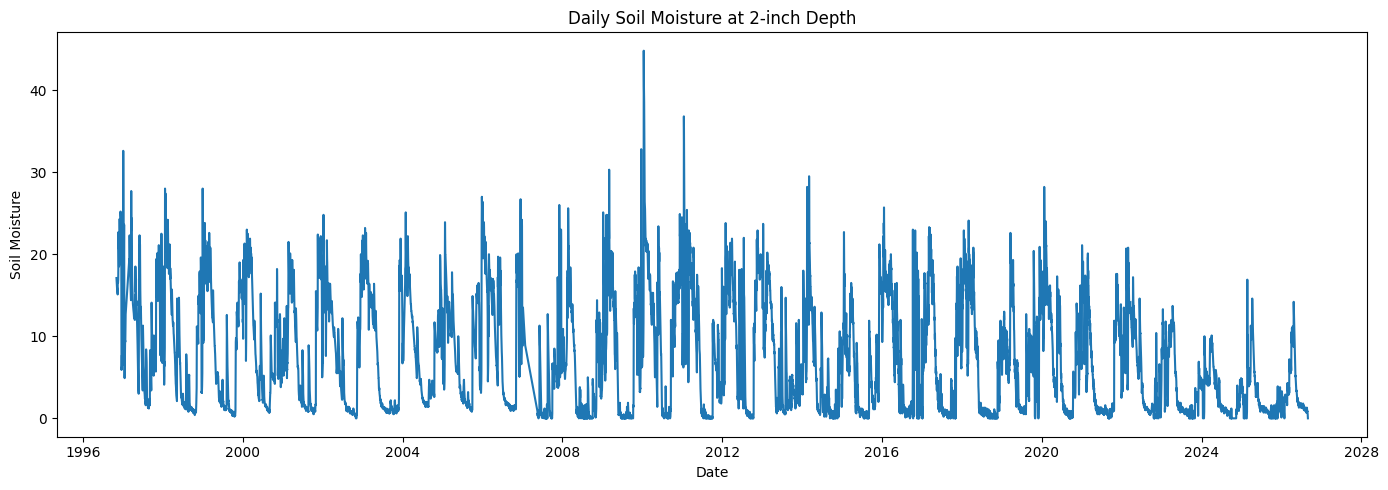

In [49]:
# plot soil moisture through time
plt.figure(figsize=(14, 5))
plt.plot(data["date"], data["value"])
plt.xlabel("Date")
plt.ylabel("Soil Moisture")
plt.title("Daily Soil Moisture at 2-inch Depth")
plt.tight_layout()
plt.show()

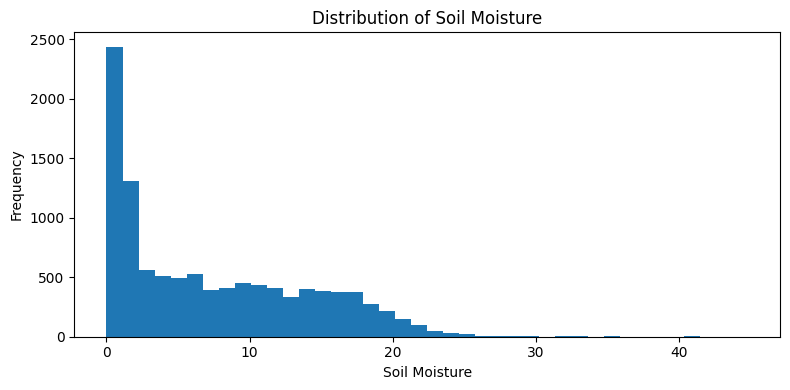

In [50]:
# target distribution
plt.figure(figsize=(8, 4))
plt.hist(data["value"], bins=40)
plt.xlabel("Soil Moisture")
plt.ylabel("Frequency")
plt.title("Distribution of Soil Moisture")
plt.tight_layout()
plt.show()


### 7.2 Weather Variables


In [51]:
# weather variable summary
weather_cols = [
    "T2M",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "ALLSKY_SFC_SW_DWN",
]

data[weather_cols].describe()

,T2M,PRECTOTCORR,RH2M,WS2M,ALLSKY_SFC_SW_DWN
count,10707.000000,10707.000000,10707.000000,10707.000000,10707.000000
mean,10.898897,0.889611,62.568560,2.517891,14.671184
std,9.409465,1.976575,18.564974,1.123301,16.610831
min,-17.690000,0.000000,20.210000,0.370000,-999.000000
25%,2.910000,0.000000,46.995000,1.680000,6.050000
50%,10.100000,0.050000,60.740000,2.300000,14.160000
75%,18.860000,0.720000,78.400000,3.125000,22.890000
max,34.840000,22.020000,100.000000,9.650000,32.520000


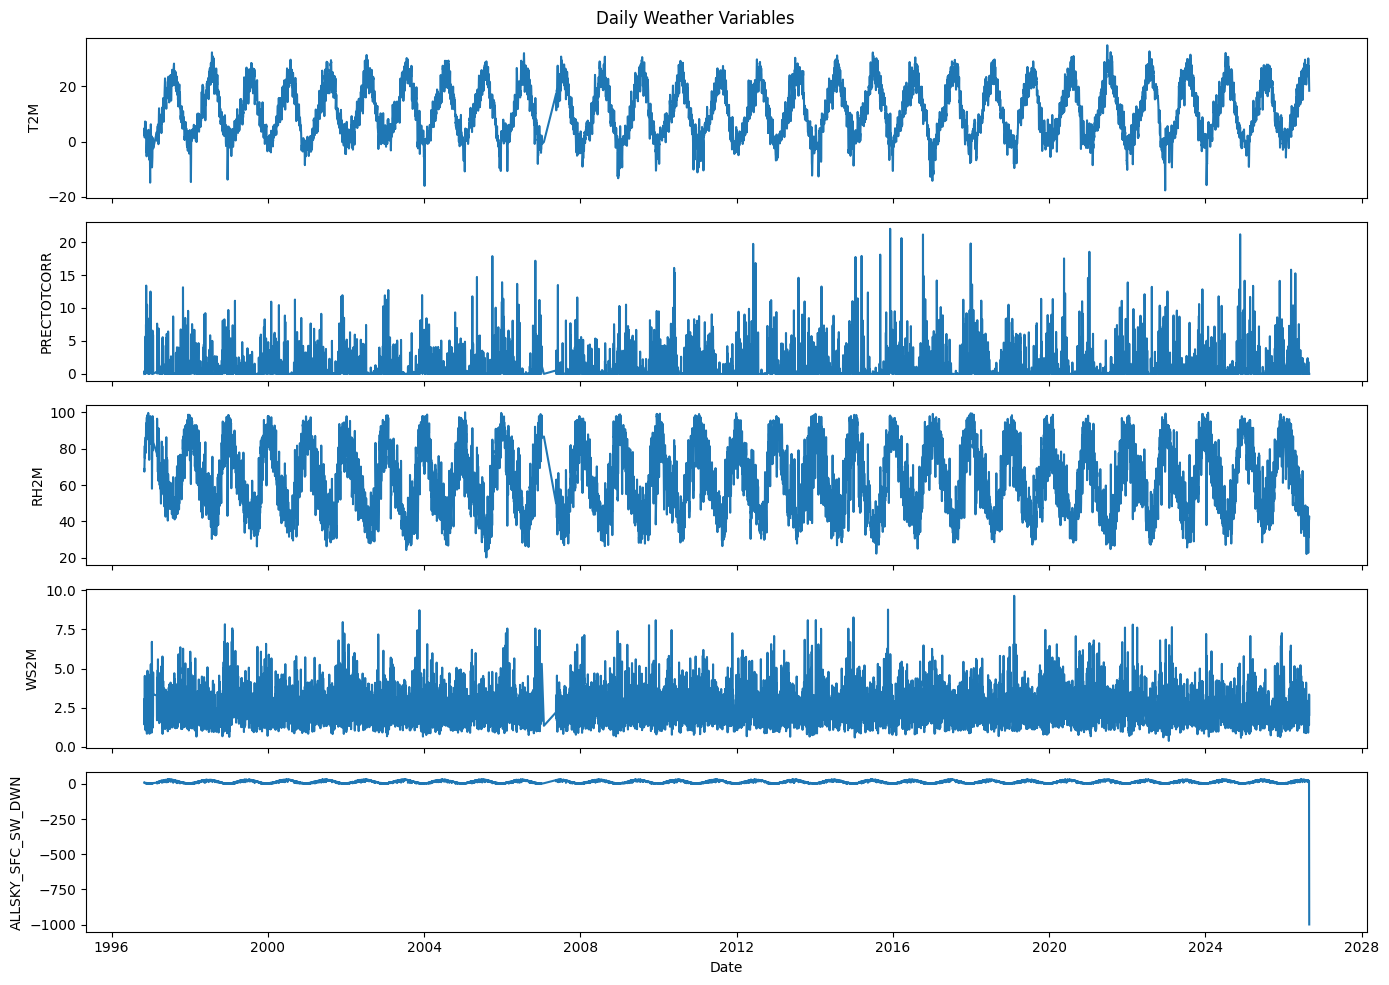

In [52]:
# weather variables through time
fig, axes = plt.subplots(len(weather_cols), 1, figsize=(14, 10), sharex=True)

for ax, col in zip(axes, weather_cols):
    ax.plot(data["date"], data[col])
    ax.set_ylabel(col)

axes[-1].set_xlabel("Date")
fig.suptitle("Daily Weather Variables")
plt.tight_layout()
plt.show()


### 7.3 Seasonality


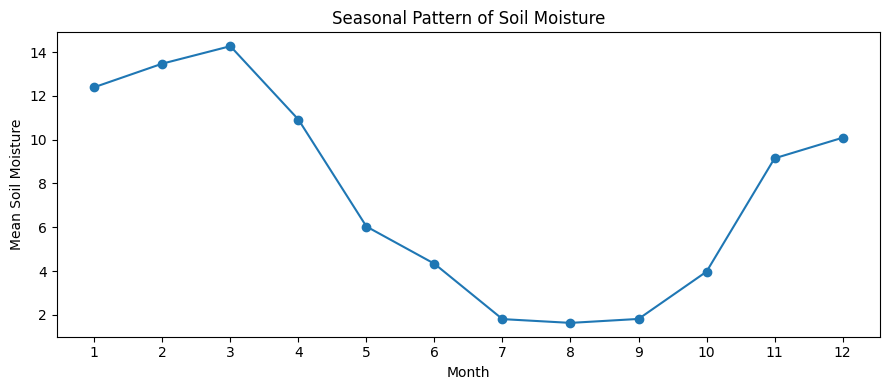

In [53]:
# calculate average soil moisture by month
monthly_soil = (
    data.assign(month=data["date"].dt.month)
    .groupby("month")["value"]
    .mean()
)

plt.figure(figsize=(9, 4))
plt.plot(monthly_soil.index, monthly_soil.values, marker="o")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Mean Soil Moisture")
plt.title("Seasonal Pattern of Soil Moisture")
plt.tight_layout()
plt.show()


### 7.4 Trends and Relationships


In [54]:
# correlation with soil moisture
data[["value"] + weather_cols].corr()["value"].sort_values(ascending=False)

value                1.000000
RH2M                 0.563464
PRECTOTCORR          0.258313
WS2M                 0.134894
ALLSKY_SFC_SW_DWN   -0.231781
T2M                 -0.519977
Name: value, dtype: float64



## 8. Time-Series Splitting



### 8.1 Create splitting


In [191]:
# create and save the fixed splits
split_dir = PROJECT_ROOT / CONFIG["paths"]["processed_data"] / "splits"
split_dir.mkdir(parents=True, exist_ok=True)

train = data[data["date"] < "2020-01-01"].copy()
val = data[
    (data["date"] >= "2020-01-01") &
    (data["date"] < "2023-01-01")
].copy()
test = data[data["date"] >= "2023-01-01"].copy()

train.to_csv(split_dir / "train.csv", index=False)
val.to_csv(split_dir / "validation.csv", index=False)
test.to_csv(split_dir / "test.csv", index=False)

print(f"Train: {len(train):,}")
print(f"Validation: {len(val):,}")
print(f"Test: {len(test):,}")
print(f"\nSaved to: {split_dir}")

Train: 8,274
Validation: 1,095
Test: 1,338

Saved to: /home/srira_linux/Desktop/CDC_Soil_Time_Series_Forecasting/data/processed/splits


### 8.2 Save ze splits

In [192]:
# save the fixed train, validation and test sets
split_dir = PROJECT_ROOT / CONFIG["paths"]["processed_data"] / "splits"
split_dir.mkdir(parents=True, exist_ok=True)

train.to_csv(split_dir / "train.csv", index=False)
val.to_csv(split_dir / "validation.csv", index=False)
test.to_csv(split_dir / "test.csv", index=False)

print(f"Saved splits to: {split_dir}")

Saved splits to: /home/srira_linux/Desktop/CDC_Soil_Time_Series_Forecasting/data/processed/splits



### 8.3 Load em up


In [193]:
# load the fixed experimental splits
train = pd.read_csv(split_dir / "train.csv", parse_dates=["date"])
val = pd.read_csv(split_dir / "validation.csv", parse_dates=["date"])
test = pd.read_csv(split_dir / "test.csv", parse_dates=["date"])

print(f"Train: {len(train):,} | {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Validation: {len(val):,} | {val['date'].min().date()} → {val['date'].max().date()}")
print(f"Test: {len(test):,} | {test['date'].min().date()} → {test['date'].max().date()}")

Train: 8,274 | 1996-11-01 → 2019-12-31
Validation: 1,095 | 2020-01-01 → 2022-12-31
Test: 1,338 | 2023-01-01 → 2026-08-30



## 9. Persistence Baseline



### 9.1 Naive Forecast


In [194]:
# load the original fixed experimental splits
split_dir = PROJECT_ROOT / CONFIG["paths"]["processed_data"] / "splits"

train = pd.read_csv(split_dir / "train.csv", parse_dates=["date"])
val = pd.read_csv(split_dir / "validation.csv", parse_dates=["date"])
test = pd.read_csv(split_dir / "test.csv", parse_dates=["date"])

# combine so the 7-day horizon works across split boundaries
baseline_data = pd.concat(
    [train, val, test],
    ignore_index=True,
).sort_values("date").reset_index(drop=True)

# 7-day-ahead target
baseline_data["target"] = baseline_data["value"].shift(-7)

# keep only rows with a known 7-day-ahead observation
baseline_data = baseline_data.dropna(
    subset=["target"]
).reset_index(drop=True)

# chronological splits
baseline_val = baseline_data[
    (baseline_data["date"] >= "2020-01-01") &
    (baseline_data["date"] < "2023-01-01")
].copy()

baseline_test = baseline_data[
    baseline_data["date"] >= "2023-01-01"
].copy()

# persistence: today's moisture predicts moisture 7 days later
val_pred = baseline_val["value"].to_numpy()
test_pred = baseline_test["value"].to_numpy()

val_actual = baseline_val["target"].to_numpy()
test_actual = baseline_test["target"].to_numpy()

print(f"Validation predictions: {len(val_pred):,}")
print(f"Test predictions: {len(test_pred):,}")

Validation predictions: 1,095
Test predictions: 1,331



### 9.2 Baseline Evaluation



In [195]:
# evaluate persistence baseline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_val_results = {
    "MAE": mean_absolute_error(val_actual, val_pred),
    "RMSE": np.sqrt(mean_squared_error(val_actual, val_pred)),
    "R²": r2_score(val_actual, val_pred),
}

baseline_test_results = {
    "MAE": mean_absolute_error(test_actual, test_pred),
    "RMSE": np.sqrt(mean_squared_error(test_actual, test_pred)),
    "R²": r2_score(test_actual, test_pred),
}

pd.Series(baseline_val_results)

MAE     2.437991
RMSE    3.868874
R²      0.569209
dtype: float64


## 10. Feature Engineering


### 10.1 Lag Features

In [196]:
# 10.1 load the fixed experimental splits
split_dir = PROJECT_ROOT / CONFIG["paths"]["processed_data"] / "splits"

train = pd.read_csv(split_dir / "train.csv", parse_dates=["date"])
val = pd.read_csv(split_dir / "validation.csv", parse_dates=["date"])
test = pd.read_csv(split_dir / "test.csv", parse_dates=["date"])

# combine so history continues across split boundaries
full_data = pd.concat([train, val, test], ignore_index=True)
full_data = full_data.sort_values("date").reset_index(drop=True)

# soil moisture history
for lag in [1, 3, 7, 14, 30]:
    full_data[f"soil_lag_{lag}"] = full_data["value"].shift(lag)

# weather history
for col in ["T2M", "RH2M", "WS2M", "ALLSKY_SFC_SW_DWN"]:
    full_data[f"{col}_lag_1"] = full_data[col].shift(1)
    full_data[f"{col}_lag_7"] = full_data[col].shift(7)

# soil moisture dynamics
full_data["soil_change_1d"] = full_data["value"] - full_data["soil_lag_1"]
full_data["soil_change_3d"] = full_data["value"] - full_data["soil_lag_3"]
full_data["soil_change_7d"] = full_data["value"] - full_data["soil_lag_7"]

# precipitation history
full_data["precip_lag_1"] = full_data["PRECTOTCORR"].shift(1)
full_data["precip_lag_3"] = full_data["PRECTOTCORR"].shift(3)
full_data["precip_lag_7"] = full_data["PRECTOTCORR"].shift(7)

# rolling features
full_data["soil_mean_7d"] = full_data["value"].rolling(7).mean()
full_data["soil_mean_14d"] = full_data["value"].rolling(14).mean()
full_data["precip_7d"] = full_data["PRECTOTCORR"].rolling(7).sum()
full_data["precip_14d"] = full_data["PRECTOTCORR"].rolling(14).sum()

# seasonal features
full_data["month"] = full_data["date"].dt.month
day_of_year = full_data["date"].dt.dayofyear
full_data["doy_sin"] = np.sin(2 * np.pi * day_of_year / 365.25)
full_data["doy_cos"] = np.cos(2 * np.pi * day_of_year / 365.25)

# 7-day-ahead target
target_lookup = full_data[["date", "value"]].copy()
target_lookup["target_date"] = target_lookup["date"] - pd.Timedelta(days=7)

full_data = full_data.merge(
    target_lookup[["target_date", "value"]].rename(columns={"value": "target"}),
    left_on="date",
    right_on="target_date",
    how="left",
).drop(columns="target_date")

# remove incomplete history/target rows
feature_data = full_data.dropna().reset_index(drop=True)

print(f"Rows after feature engineering: {len(feature_data):,}")
print(f"Period: {feature_data['date'].min().date()} → {feature_data['date'].max().date()}")
print(f"Total columns: {feature_data.shape[1]}")
print([c for c in feature_data.columns if "soil_change" in c])

# save
feature_file = PROJECT_ROOT / CONFIG["paths"]["processed_data"] / "engineered_features.csv"
feature_data.to_csv(feature_file, index=False)

print("Saved engineered dataset to:")
print(feature_file)

Rows after feature engineering: 10,633
Period: 1996-12-01 → 2026-08-23
Total columns: 34
['soil_change_1d', 'soil_change_3d', 'soil_change_7d']
Saved engineered dataset to:
/home/srira_linux/Desktop/CDC_Soil_Time_Series_Forecasting/data/processed/engineered_features.csv


### 10.2 Rolling Features

In [197]:
# rolling soil moisture features
full_data["soil_mean_7d"] = (full_data["value"].rolling(7).mean())
full_data["soil_mean_14d"] = (full_data["value"].rolling(14).mean())

# rolling precipitation accumulation
full_data["precip_7d"] = (full_data["PRECTOTCORR"].rolling(7).sum())
full_data["precip_14d"] = (full_data["PRECTOTCORR"].rolling(14).sum())

# soil moisture dynamics
full_data["soil_change_1d"] = full_data["value"] - full_data["soil_lag_1"]
full_data["soil_change_3d"] = full_data["value"] - full_data["soil_lag_3"]
full_data["soil_change_7d"] = full_data["value"] - full_data["soil_lag_7"]

### 10.3 Temporal Features

In [198]:
# calendar features
full_data["month"] = full_data["date"].dt.month

# annual seasonal cycle
day_of_year = full_data["date"].dt.dayofyear

full_data["doy_sin"] = np.sin(2 * np.pi * day_of_year / 365.25)
full_data["doy_cos"] = np.cos(2 * np.pi * day_of_year / 365.25)

### 10.4 Exogenous Variables

In [199]:
# define exogenous weather features (were already created in 10.1, this just a list)
exogenous_features = [
    "T2M_lag_1",
    "T2M_lag_7",
    "RH2M_lag_1",
    "RH2M_lag_7",
    "WS2M_lag_1",
    "WS2M_lag_7",
    "ALLSKY_SFC_SW_DWN_lag_1",
    "ALLSKY_SFC_SW_DWN_lag_7",
    "precip_lag_1",
    "precip_lag_3",
    "precip_lag_7",
    "precip_7d",
    "precip_14d",
]

print("Exogenous features:")
print(exogenous_features)

Exogenous features:
['T2M_lag_1', 'T2M_lag_7', 'RH2M_lag_1', 'RH2M_lag_7', 'WS2M_lag_1', 'WS2M_lag_7', 'ALLSKY_SFC_SW_DWN_lag_1', 'ALLSKY_SFC_SW_DWN_lag_7', 'precip_lag_1', 'precip_lag_3', 'precip_lag_7', 'precip_7d', 'precip_14d']


### 10.5 Target + final dataset

In [209]:
### 10.5 Target + final dataset
# exact 7-calendar-day-ahead target
feature_data = full_data.dropna().copy()

feature_data["target_date"] = feature_data["date"] + pd.Timedelta(days=7)

target_lookup = full_data[["date", "value"]].rename(
    columns={
        "date": "target_date",
        "value": "target",
    }
)

feature_data = feature_data.merge(
    target_lookup,
    on="target_date",
    how="left",
)

# remove rows without an exact observation 7 calendar days later
feature_data = feature_data.dropna(subset=["target"]).reset_index(drop=True)

print(f"Rows after feature engineering: {len(feature_data):,}")
print(
    f"Period: {feature_data['date'].min().date()} → "
    f"{feature_data['date'].max().date()}"
)
print(f"Total columns: {feature_data.shape[1]}")

Rows after feature engineering: 10,633
Period: 1996-12-01 → 2026-08-23
Total columns: 37


### 10.6 Save Engineered Dataset

In [210]:
# save engineered dataset
feature_file = (
    PROJECT_ROOT
    / CONFIG["paths"]["processed_data"]
    / "engineered_features.csv"
)

feature_data.to_csv(feature_file, index=False)

print("Saved engineered dataset to:")
print(feature_file)

Saved engineered dataset to:
/home/srira_linux/Desktop/CDC_Soil_Time_Series_Forecasting/data/processed/engineered_features.csv


## 11. SARIMA

### 11.1 Model Specification

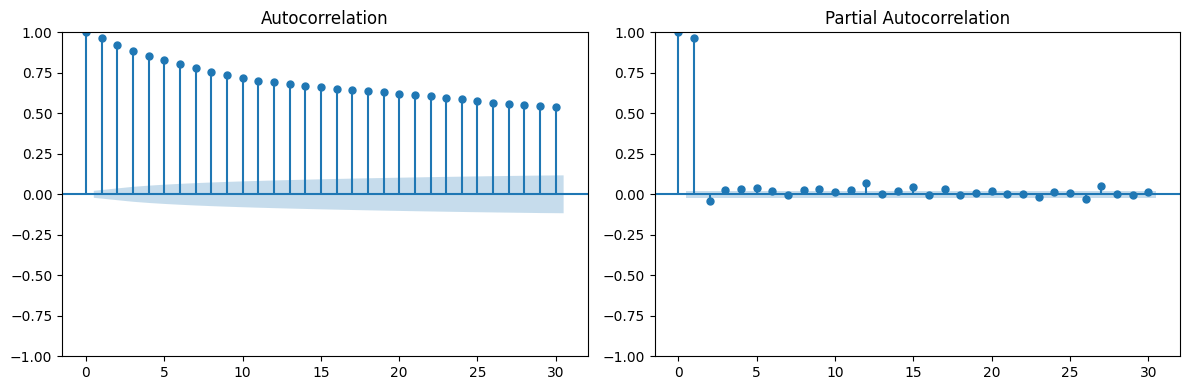

In [211]:
# load the fixed experimental splits
split_dir = PROJECT_ROOT / CONFIG["paths"]["processed_data"] / "splits"

train = pd.read_csv(split_dir / "train.csv", parse_dates=["date"])
val = pd.read_csv(split_dir / "validation.csv", parse_dates=["date"])
test = pd.read_csv(split_dir / "test.csv", parse_dates=["date"])

# SARIMA training series
sarima_train = train["value"].reset_index(drop=True)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(sarima_train, lags=30, ax=axes[0])
plot_pacf(sarima_train, lags=30, ax=axes[1])
plt.tight_layout()
plt.show()

### 11.2 Training

In [212]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA uses soil moisture history only
sarima_train = train["value"].reset_index(drop=True)

sarima_model = SARIMAX(
    sarima_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             value   No. Observations:                 8274
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood              -16868.054
Date:                           Wed, 02 Sep 2026   AIC                          33746.107
Time:                                   19:34:12   BIC                          33781.205
Sample:                                        0   HQIC                         33758.101
                                          - 8274                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9644      0.003    308.337      0.000       0.958       0.971
ma.L1         -1.0000      0.028    -35.727

### 11.3 Validatoin Forecasting

In [213]:
# 7-day-ahead walk-forward validation
sarima_val_pred = []
sarima_current = sarima_fit

for i in range(len(val) - 7):
    actual = val["value"].iloc[i]

    # reveal today's observation before forecasting
    sarima_current = sarima_current.append([actual], refit=False)

    # forecast from t to t+7
    forecast = sarima_current.forecast(steps=7)
    sarima_val_pred.append(forecast.iloc[-1])

sarima_val_pred = np.asarray(sarima_val_pred)

sarima_val_actual = val["value"].iloc[7:].to_numpy()

print(f"Validation predictions: {len(sarima_val_pred):,}")
print(f"Validation actuals: {len(sarima_val_actual):,}")

Validation predictions: 1,088
Validation actuals: 1,088


### 11.4 Validation metrics

In [214]:
# 7-day-ahead validation metrics
sarima_val_results = {
    "MAE": mean_absolute_error(
        sarima_val_actual,
        sarima_val_pred,
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            sarima_val_actual,
            sarima_val_pred,
        )
    ),
    "R²": r2_score(
        sarima_val_actual,
        sarima_val_pred,
    ),
}

pd.Series(sarima_val_results)

MAE     2.622174
RMSE    3.649103
R²      0.619080
dtype: float64

## 12. XGBoost


### 12.1 Data prep


In [215]:
# load engineered features
feature_file = (
    PROJECT_ROOT
    / CONFIG["paths"]["processed_data"]
    / "engineered_features.csv"
)

feature_data = pd.read_csv(feature_file, parse_dates=["date"])

# chronological splits
train_feat = feature_data[feature_data["date"] < "2020-01-01"].copy()

val_feat = feature_data[
    (feature_data["date"] >= "2020-01-01") &
    (feature_data["date"] < "2023-01-01")
].copy()

test_feat = feature_data[
    feature_data["date"] >= "2023-01-01"
].copy()

print(
    f"Train: {len(train_feat):,} | "
    f"Validation: {len(val_feat):,} | "
    f"Test: {len(test_feat):,}"
)

Train: 8,208 | Validation: 1,094 | Test: 1,331



### 12.2 FEature def


In [216]:
# model features
feature_cols = [
    "soil_lag_1",
    "soil_lag_3",
    "soil_lag_7",
    "soil_lag_14",
    "soil_lag_30",
    "soil_mean_7d",
    "soil_mean_14d",
    "soil_change_1d",
    "soil_change_3d",
    "soil_change_7d",
    "month",
    "doy_sin",
    "doy_cos",
] + exogenous_features

# remove accidental duplicates
feature_cols = list(dict.fromkeys(feature_cols))

print(f"Features: {len(feature_cols)}")
print(feature_cols)

X_train = train_feat[feature_cols]
X_val = val_feat[feature_cols]
X_test = test_feat[feature_cols]

y_train = train_feat["target"]
y_val = val_feat["target"]
y_test = test_feat["target"]

Features: 26
['soil_lag_1', 'soil_lag_3', 'soil_lag_7', 'soil_lag_14', 'soil_lag_30', 'soil_mean_7d', 'soil_mean_14d', 'soil_change_1d', 'soil_change_3d', 'soil_change_7d', 'month', 'doy_sin', 'doy_cos', 'T2M_lag_1', 'T2M_lag_7', 'RH2M_lag_1', 'RH2M_lag_7', 'WS2M_lag_1', 'WS2M_lag_7', 'ALLSKY_SFC_SW_DWN_lag_1', 'ALLSKY_SFC_SW_DWN_lag_7', 'precip_lag_1', 'precip_lag_3', 'precip_lag_7', 'precip_7d', 'precip_14d']



### 12.3 train


In [217]:
import xgboost as xgb
from xgboost import XGBRegressor

print(f"XGBoost version: {xgb.__version__}")

xgb_model = XGBRegressor(
    n_estimators=2000,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric="rmse",
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f"Best iteration: {xgb_model.best_iteration}")
print("XGBoost training complete.")

XGBoost version: 3.4.1
Best iteration: 147
XGBoost training complete.


### 12.4 - Val prediction

In [218]:
xgb_val_pred = xgb_model.predict(X_val)

print(f"Validation predictions: {len(xgb_val_pred):,}")

Validation predictions: 1,094


### 12.5 - Validation metrics

In [219]:
xgb_val_results = {
    "MAE": mean_absolute_error(
        y_val,
        xgb_val_pred,
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y_val,
            xgb_val_pred,
        )
    ),
    "R²": r2_score(
        y_val,
        xgb_val_pred,
    ),
}

pd.Series(xgb_val_results)

MAE     2.268274
RMSE    3.308872
R²      0.685041
dtype: float64

### 12.6 - feature importance cell

In [220]:
importance = (
    pd.Series(
        xgb_model.feature_importances_,
        index=feature_cols,
    )
    .sort_values(ascending=False)
)

importance.head(15)

soil_lag_1        0.322327
soil_mean_7d      0.150780
soil_mean_14d     0.103872
T2M_lag_1         0.072104
RH2M_lag_1        0.050976
month             0.039436
doy_cos           0.029179
T2M_lag_7         0.023400
soil_change_3d    0.019413
soil_change_1d    0.017886
soil_lag_14       0.013664
soil_lag_30       0.013383
soil_lag_3        0.012806
doy_sin           0.012686
precip_14d        0.012186
dtype: float32



## 13. LSTM



### 13.1 Sequence Construction


In [221]:
from sklearn.preprocessing import StandardScaler

SEQUENCE_LENGTH = 30
lstm_feature_cols = feature_cols

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(train_feat[lstm_feature_cols])
X_val_scaled = scaler_X.transform(val_feat[lstm_feature_cols])
X_test_scaled = scaler_X.transform(test_feat[lstm_feature_cols])

y_train_scaled = scaler_y.fit_transform(train_feat[["target"]]).flatten()
y_val_scaled = scaler_y.transform(val_feat[["target"]]).flatten()
y_test_scaled = scaler_y.transform(test_feat[["target"]]).flatten()

def make_train_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i - seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

# training sequences
X_train_seq, y_train_seq = make_train_sequences(
    X_train_scaled,
    y_train_scaled,
    SEQUENCE_LENGTH,
)

# validation sequences: include last 30 training days as history
X_val_context = np.vstack([
    X_train_scaled[-SEQUENCE_LENGTH:],
    X_val_scaled,
])

y_val_context = np.concatenate([
    y_train_scaled[-SEQUENCE_LENGTH:],
    y_val_scaled,
])

X_val_seq, y_val_seq = make_train_sequences(
    X_val_context,
    y_val_context,
    SEQUENCE_LENGTH,
)

# test sequences: include last 30 validation days as history
X_test_context = np.vstack([
    X_val_scaled[-SEQUENCE_LENGTH:],
    X_test_scaled,
])

y_test_context = np.concatenate([
    y_val_scaled[-SEQUENCE_LENGTH:],
    y_test_scaled,
])

X_test_seq, y_test_seq = make_train_sequences(
    X_test_context,
    y_test_context,
    SEQUENCE_LENGTH,
)

print("Train:", X_train_seq.shape, y_train_seq.shape)
print("Validation:", X_val_seq.shape, y_val_seq.shape)
print("Test:", X_test_seq.shape, y_test_seq.shape)

Train: (8178, 30, 26) (8178,)
Validation: (1094, 30, 26) (1094,)
Test: (1331, 30, 26) (1331,)


In [225]:
%pip uninstall -y tensorflow
%pip install tensorflow

Found existing installation: tensorflow 2.21.0
Uninstalling tensorflow-2.21.0:
  Successfully uninstalled tensorflow-2.21.0
Note: you may need to restart the kernel to use updated packages.
  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl (572.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 7.9 MB/s  0:00:0014.1 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 15.0 MB/s  0:00:00 18.0 MB/s eta 0:00:01
Using cached absl_py-2.5.0-py3-none-any.whl (137 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 14.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 12.3 MB/s  0:00:012.7 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 12.5 MB/s  0:00:012.6 MB/s


### 13.2 Model Architecture


In [226]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

n_features = X_train_seq.shape[2]

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1),
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
)

I0000 00:00:1788358156.085764  131968 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788358156.086124  131968 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1788358156.679169  131968 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/srira_linux/Desktop/Autonxt_Projects/autonxt_inst_segm/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



### 13.3 Training


In [227]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.3734 - val_loss: 0.2598
Epoch 2/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.3205 - val_loss: 0.2760
Epoch 3/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.2833 - val_loss: 0.3054
Epoch 4/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.2534 - val_loss: 0.3213
Epoch 5/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.2290 - val_loss: 0.3004
Epoch 6/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.2051 - val_loss: 0.3310
Epoch 7/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1819 - val_loss: 0.3467
Epoch 8/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1620 - val_loss: 0.3783
Epoch 9/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1596 - val_loss: 0.3809
Epoch 10/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1460 - val_loss: 0.3938
Epoch 11/200
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1380 - val_loss: 0.4072
Epoch 12/200
256/256 ━━━━━━━━━


### 13.4 Forecasting


In [228]:
lstm_val_pred_scaled = lstm_model.predict(
    X_val_seq,
    verbose=0,
).flatten()

lstm_val_pred = scaler_y.inverse_transform(
    lstm_val_pred_scaled.reshape(-1, 1)
).flatten()

lstm_val_actual = scaler_y.inverse_transform(
    y_val_seq.reshape(-1, 1)
).flatten()

print(f"Validation predictions: {len(lstm_val_pred):,}")

Validation predictions: 1,094



### 13.5 Evaluation


In [229]:
lstm_val_results = {
    "MAE": mean_absolute_error(
        lstm_val_actual,
        lstm_val_pred,
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            lstm_val_actual,
            lstm_val_pred,
        )
    ),
    "R²": r2_score(
        lstm_val_actual,
        lstm_val_pred,
    ),
}

pd.Series(lstm_val_results)

MAE     2.381595
RMSE    3.498644
R²      0.647878
dtype: float64


## 14. Model Comparison


In [230]:
# Stage 14: compare validation performance

comparison = pd.DataFrame({
    "Persistence": baseline_val_results,
    "SARIMA": sarima_val_results,
    "XGBoost": xgb_val_results,
    "LSTM": lstm_val_results,
}).T

comparison = comparison.sort_values("RMSE")
comparison

,MAE,RMSE,R²
XGBoost,2.268274,3.308872,0.685041
LSTM,2.381595,3.498644,0.647878
SARIMA,2.622174,3.649103,0.619080
Persistence,2.437991,3.868874,0.569209


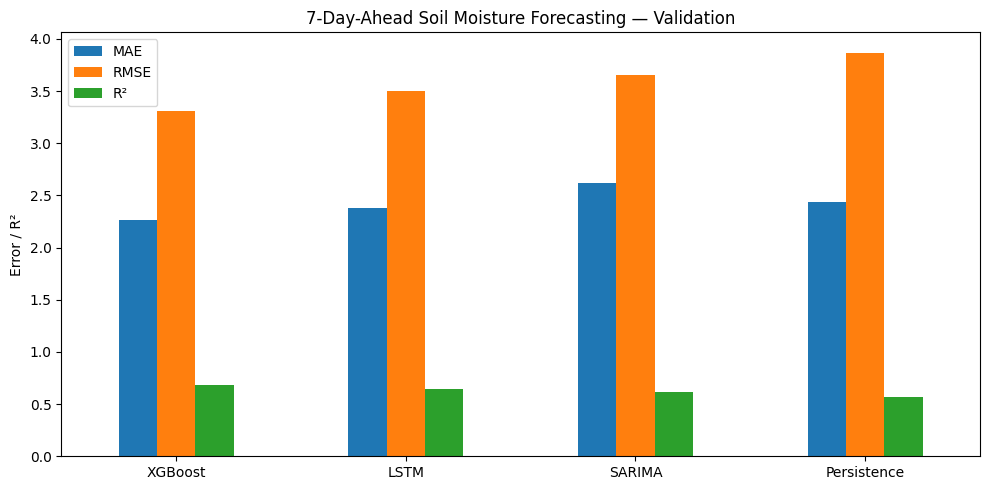

In [231]:
comparison.plot(kind="bar", figsize=(10, 5))
plt.title("7-Day-Ahead Soil Moisture Forecasting — Validation")
plt.ylabel("Error / R²")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 15. Final test eval


In [232]:
# Stage 15: final test evaluation

# Persistence
persistence_test_results = {
    "MAE": mean_absolute_error(test_actual, test_pred),
    "RMSE": np.sqrt(mean_squared_error(test_actual, test_pred)),
    "R²": r2_score(test_actual, test_pred),
}

# XGBoost
xgb_test_pred = xgb_model.predict(X_test)

xgb_test_results = {
    "MAE": mean_absolute_error(y_test, xgb_test_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, xgb_test_pred)),
    "R²": r2_score(y_test, xgb_test_pred),
}

# LSTM
lstm_test_pred_scaled = lstm_model.predict(
    X_test_seq,
    verbose=0,
).flatten()

lstm_test_pred = scaler_y.inverse_transform(
    lstm_test_pred_scaled.reshape(-1, 1)
).flatten()

lstm_test_actual = scaler_y.inverse_transform(
    y_test_seq.reshape(-1, 1)
).flatten()

lstm_test_results = {
    "MAE": mean_absolute_error(lstm_test_actual, lstm_test_pred),
    "RMSE": np.sqrt(mean_squared_error(lstm_test_actual, lstm_test_pred)),
    "R²": r2_score(lstm_test_actual, lstm_test_pred),
}

# SARIMA
sarima_test_pred = []
sarima_current = sarima_fit

for i in range(len(val)):
    sarima_current = sarima_current.append(
        [val["value"].iloc[i]],
        refit=False,
    )

for i in range(len(test) - 7):
    actual = test["value"].iloc[i]
    sarima_current = sarima_current.append([actual], refit=False)
    forecast = sarima_current.forecast(steps=7)
    sarima_test_pred.append(forecast.iloc[-1])

sarima_test_pred = np.asarray(sarima_test_pred)
sarima_test_actual = test["value"].iloc[7:].to_numpy()

sarima_test_results = {
    "MAE": mean_absolute_error(sarima_test_actual, sarima_test_pred),
    "RMSE": np.sqrt(mean_squared_error(sarima_test_actual, sarima_test_pred)),
    "R²": r2_score(sarima_test_actual, sarima_test_pred),
}

# final comparison
test_comparison = pd.DataFrame({
    "Persistence": persistence_test_results,
    "SARIMA": sarima_test_results,
    "XGBoost": xgb_test_results,
    "LSTM": lstm_test_results,
}).T

test_comparison = test_comparison.sort_values("RMSE")
test_comparison

,MAE,RMSE,R²
Persistence,1.161007,1.969495,0.653745
SARIMA,1.777059,2.159983,0.583527
LSTM,2.508225,3.403399,-0.033978
XGBoost,2.529682,3.485755,-0.084625



## 16. Conclusions



## 17. Limitations & Future Work

# DELETE

VALIDATION
count    1095.000000
mean        6.634977
std         5.944011
min         0.000000
25%         1.100000
50%         4.700000
75%        11.400000
max        28.200000
Name: value, dtype: float64
count    1095.000000
mean        6.583288
std         5.897254
min         0.000000
25%         1.100000
50%         4.700000
75%        11.300000
max        28.200000
Name: target, dtype: float64

TEST
count    1331.000000
mean        3.275582
std         3.359428
min         0.000000
25%         0.900000
50%         1.800000
75%         4.700000
max        16.900000
Name: value, dtype: float64
count    1331.000000
mean        3.237040
std         3.348269
min         0.000000
25%         0.900000
50%         1.700000
75%         4.700000
max        16.900000
Name: target, dtype: float64
Validation target mean: 6.579524680073126
Validation target std: 5.898636106473317
Test target mean: 3.2370398196844477
Test target std: 3.348268987955782
XGB validation: {'MAE': 2.268274291494429,

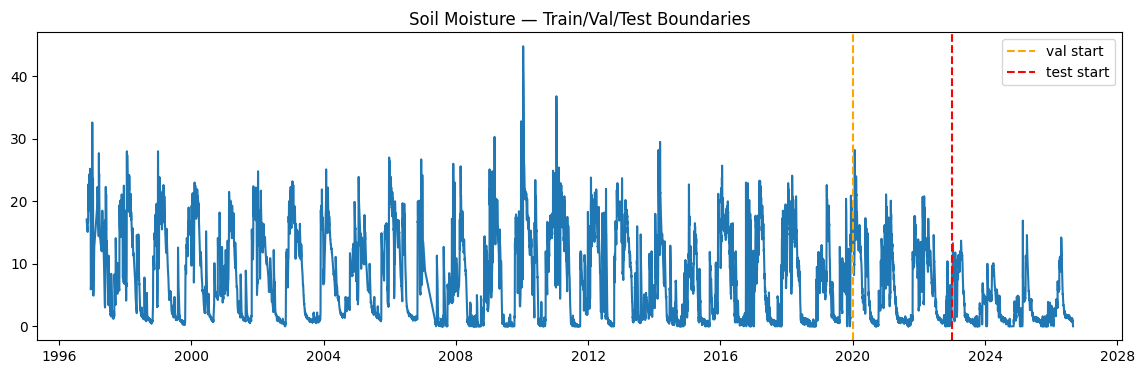

In [235]:
print("VALIDATION")
print(baseline_val["value"].describe())
print(baseline_val["target"].describe())

print("\nTEST")
print(baseline_test["value"].describe())
print(baseline_test["target"].describe())

print("Validation target mean:", y_val.mean())
print("Validation target std:", y_val.std())
print("Test target mean:", y_test.mean())
print("Test target std:", y_test.std())

print("XGB validation:", xgb_val_results)
print("XGB test:", xgb_test_results)

print("LSTM validation:", lstm_val_results)
print("LSTM test:", lstm_test_results)

print("Train target stats:")
print(train_feat["target"].describe())

print("\nTest target stats:")
print(test_feat["target"].describe())

# visualize the shift directly
plt.figure(figsize=(14, 4))
plt.plot(data["date"], data["value"])
plt.axvline(pd.Timestamp("2020-01-01"), color="orange", linestyle="--", label="val start")
plt.axvline(pd.Timestamp("2023-01-01"), color="red", linestyle="--", label="test start")
plt.legend()
plt.title("Soil Moisture — Train/Val/Test Boundaries")
plt.show()

           mean       std  count
year                            
1996  16.288525  5.816273     61
1997  10.819520  6.247309    333
1998   8.577410  7.376739    363
1999   8.715978  7.104292    363
2000   8.903022  6.341487    364
2001   8.357143  6.558067    364
2002   8.077808  6.364654    365
2003   7.909315  7.307472    365
2004   8.594247  5.628542    365
2005   8.269863  5.973520    365
2006   9.964738  7.326956    363
2007   4.259740  4.755562    231
2008   5.385000  5.767800    360
2009   8.074105  7.596469    363
2010  11.564932  8.293946    365
2011   8.419726  7.563202    365
2012  10.490164  7.298524    366
2013   6.827123  5.664067    365
2014   5.887363  6.114996    364
2015   6.248767  5.620506    365
2016   8.571038  7.333678    366
2017   7.411507  6.948154    365
2018   6.900822  7.056333    365
2019   7.357851  5.412428    363
2020   7.875137  6.283085    366
2021   6.034890  6.029566    364
2022   5.989863  5.293644    365
2023   4.183288  4.017690    365
2024   2.8

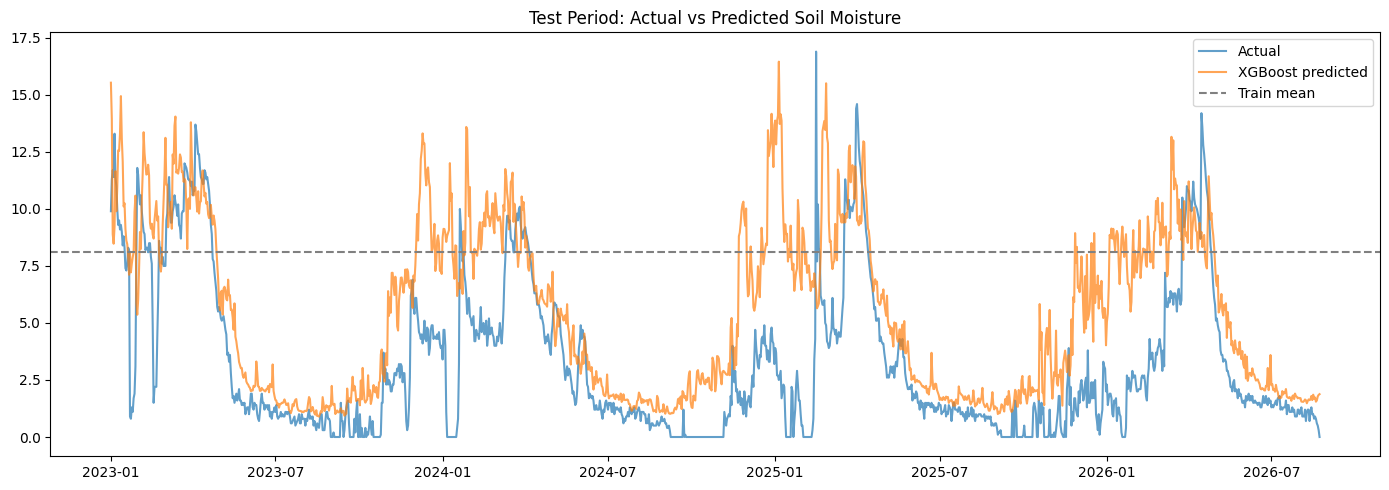

In [236]:
# check if this is a genuine trend or a step-change (sensor issue, station move, etc.)
yearly_stats = data.assign(year=data["date"].dt.year).groupby("year")["value"].agg(["mean", "std", "count"])
print(yearly_stats)

# visualize actual vs predicted on test to see the bias direction directly
plt.figure(figsize=(14, 5))
plt.plot(test_feat["date"], y_test, label="Actual", alpha=0.7)
plt.plot(test_feat["date"], xgb_model.predict(X_test), label="XGBoost predicted", alpha=0.7)
plt.axhline(train_feat["target"].mean(), color="gray", linestyle="--", label="Train mean")
plt.legend()
plt.title("Test Period: Actual vs Predicted Soil Moisture")
plt.tight_layout()
plt.show()

# DELETE

In [237]:
# Stage 16: walk-forward XGBoost evaluation

fold_boundaries = [
    ("2010-01-01", "2018-01-01", "2018-01-01", "2019-01-01"),
    ("2010-01-01", "2019-01-01", "2019-01-01", "2020-01-01"),
    ("2010-01-01", "2020-01-01", "2020-01-01", "2021-01-01"),
    ("2010-01-01", "2021-01-01", "2021-01-01", "2022-01-01"),
    ("2010-01-01", "2022-01-01", "2022-01-01", "2023-01-01"),
    ("2010-01-01", "2023-01-01", "2023-01-01", "2024-01-01"),
]

fold_results = []

for train_start, train_end, test_start, test_end in fold_boundaries:
    tr = feature_data[
        (feature_data["date"] >= train_start) &
        (feature_data["date"] < train_end)
    ]
    te = feature_data[
        (feature_data["date"] >= test_start) &
        (feature_data["date"] < test_end)
    ]

    model = XGBRegressor(
        n_estimators=2000,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(tr[feature_cols], tr["target"])
    pred = model.predict(te[feature_cols])

    fold_results.append({
        "test_period": f"{test_start[:4]}",
        "MAE": mean_absolute_error(te["target"], pred),
        "RMSE": np.sqrt(mean_squared_error(te["target"], pred)),
        "R²": r2_score(te["target"], pred),
        "train_mean": tr["target"].mean(),
        "test_mean": te["target"].mean(),
    })

walk_forward_results = pd.DataFrame(fold_results)
walk_forward_results

,test_period,MAE,RMSE,R²,train_mean,test_mean
0,2018,2.086197,2.926415,0.826884,8.182774,6.862192
1,2019,3.878939,5.434377,0.038481,8.036043,7.504432
2,2020,2.664932,3.781101,0.642704,7.983406,7.896448
3,2021,2.287168,3.228362,0.690713,7.975474,5.760882
4,2022,2.528640,3.690980,0.511579,7.791726,6.073151
5,2023,1.871987,2.610415,0.569476,7.659388,4.113425


In [238]:
# Stage 17: walk-forward XGBoost vs persistence

fold_results = []

for train_start, train_end, test_start, test_end in fold_boundaries:
    tr = feature_data[
        (feature_data["date"] >= train_start) &
        (feature_data["date"] < train_end)
    ]
    te = feature_data[
        (feature_data["date"] >= test_start) &
        (feature_data["date"] < test_end)
    ]

    model = XGBRegressor(
        n_estimators=2000,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(tr[feature_cols], tr["target"])
    xgb_pred = model.predict(te[feature_cols])

    persistence_pred = te["value"].to_numpy()
    actual = te["target"].to_numpy()

    fold_results.append({
        "test_period": test_start[:4],
        "XGB_RMSE": np.sqrt(mean_squared_error(actual, xgb_pred)),
        "XGB_R²": r2_score(actual, xgb_pred),
        "Persistence_RMSE": np.sqrt(mean_squared_error(actual, persistence_pred)),
        "Persistence_R²": r2_score(actual, persistence_pred),
    })

walk_forward_comparison = pd.DataFrame(fold_results)
walk_forward_comparison

,test_period,XGB_RMSE,XGB_R²,Persistence_RMSE,Persistence_R²
0,2018,2.926415,0.826884,3.460545,0.757922
1,2019,5.434377,0.038481,4.869186,0.228082
2,2020,3.781101,0.642704,4.165313,0.566402
3,2021,3.228362,0.690713,3.574496,0.620836
4,2022,3.690980,0.511579,3.846557,0.469537
5,2023,2.610415,0.569476,2.342572,0.653292
